In [3]:
import matplotlib
from datascience import *
%matplotlib inline
import matplotlib.pyplot as plots
import numpy as np
plots.style.use('fivethirtyeight')

In [4]:
little_women = Table.read_table('/Users/fatemeh/Downloads/little_women.csv')
little_women = little_women.move_to_start('Periods')
little_women.show(3)

FileNotFoundError: [Errno 2] No such file or directory: '/Users/fatemeh/Downloads/little_women.csv'

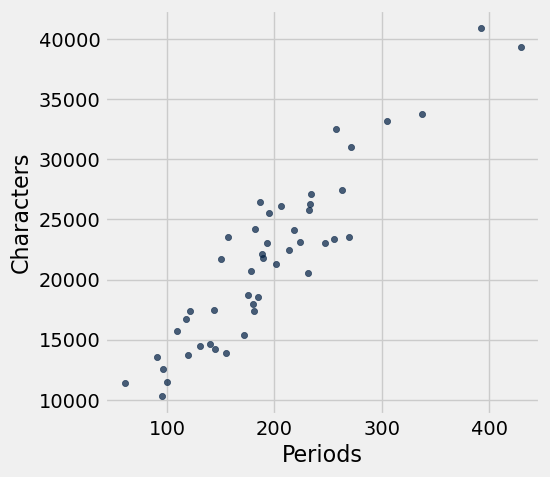

In [ ]:
little_women.scatter('Periods', 'Characters')

In [ ]:

# Copy-pasted from above
def standard_units(x):
    """ Converts an array x to standard units """
    return (x - np.mean(x)) / np.std(x)

def correlation(t, x, y):
    """ Computes correlation: t is a table, and x and y are column names """
    x_su = standard_units(t.column(x))
    y_su = standard_units(t.column(y))
    return np.mean(x_su * y_su)

correlation(little_women, 'Periods', 'Characters')

0.92295768958548163

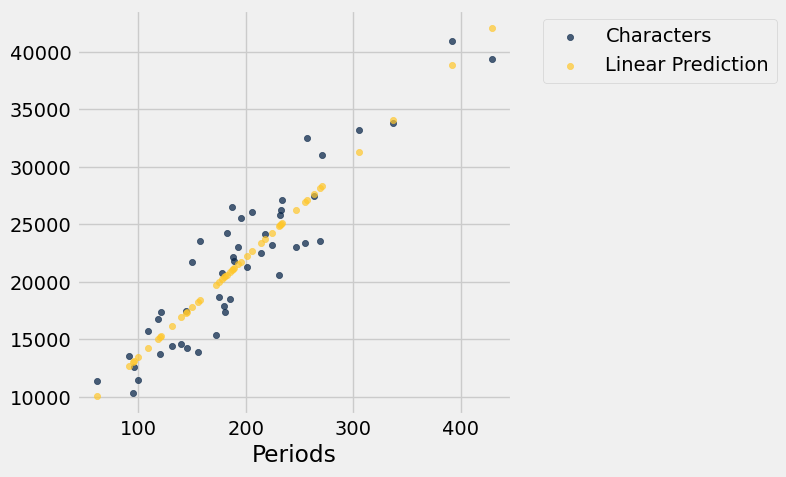

In [ ]:
def correlation(t, label_x, label_y):
    return np.mean(standard_units(t.column(label_x))*standard_units(t.column(label_y)))

def slope(t, label_x, label_y):
    r = correlation(t, label_x, label_y)
    return r*np.std(t.column(label_y))/np.std(t.column(label_x))

def intercept(t, label_x, label_y):
    return np.mean(t.column(label_y)) - slope(t, label_x, label_y)*np.mean(t.column(label_x))

def fit(table, x, y):
    """Return the height of the regression line at each x value."""
    a = slope(table, x, y)
    b = intercept(table, x, y)
    return a * table.column(x) + b

lw_with_predictions = little_women.with_column('Linear Prediction', fit(little_women, 'Periods', 'Characters'))
lw_with_predictions.scatter('Periods')

In [ ]:
actual = lw_with_predictions.column('Characters')
predicted = lw_with_predictions.column('Linear Prediction')
errors = actual - predicted

In [ ]:
lw_with_predictions.with_column('Error', errors)

Periods,Characters,Linear Prediction,Error
189,21759,21183.6,575.403
188,22148,21096.6,1051.38
231,20558,24836.7,-4278.67
195,25526,21705.5,3820.54
255,23395,26924.1,-3529.13
140,14622,16921.7,-2299.68
131,14431,16138.9,-1707.88
214,22476,23358,-882.043
337,33767,34056.3,-289.317
185,18508,20835.7,-2327.69


In [ ]:
lw_reg_slope = slope(little_women, 'Periods', 'Characters')
lw_reg_intercept = intercept(little_women, 'Periods', 'Characters')

In [ ]:
print('Slope of Regression Line:    ', np.round(lw_reg_slope), 'characters per period')
print('Intercept of Regression Line:', np.round(lw_reg_intercept), 'characters')

def lw_errors(slope, intercept):
    # Calculate predicted values based on slope and intercept
    predicted_values = slope * little_women.column('Periods') + intercept
    actual_values = little_women.column('Characters')
    
lw_errors(lw_reg_slope, lw_reg_intercept)

Slope of Regression Line:     87.0 characters per period
Intercept of Regression Line: 4745.0 characters


In [ ]:
def lw_rmse(slope, intercept):
    lw_errors(slope, intercept)
    x = little_women.column('Periods')
    y = little_women.column('Characters')
    fitted = slope * x + intercept
    mse = np.mean((y - fitted) ** 2)
    print("Root mean squared error:", mse ** 0.5)

In [ ]:
lw_rmse(50, 10000)


Root mean squared error: 4322.16783177


In [ ]:
 lw_rmse(-100, 50000)

Root mean squared error: 16710.1198374


In [ ]:
lw_rmse(90, 4000)

Root mean squared error: 2715.53910638


In [ ]:
lw_rmse(lw_reg_slope, lw_reg_intercept)

Root mean squared error: 2701.69078531


In [ ]:
def lw_mse(any_slope, any_intercept):
    x = little_women.column('Periods')
    y = little_women.column('Characters')
    fitted = any_slope*x + any_intercept
    return np.mean((y - fitted) ** 2)

In [ ]:
lw_mse(lw_reg_slope, lw_reg_intercept)**0.5

2701.690785311856

In [ ]:
lw_rmse(lw_reg_slope, lw_reg_intercept)

Root mean squared error: 2701.69078531


In [ ]:
lw_mse(-100, 50000)**0.5

16710.119837353752

In [ ]:
lw_mse(90, 4000)**0.5

2715.5391063834586

In [ ]:
best = minimize(lw_mse)
best

array([   86.97784117,  4744.78484535])

In [ ]:
print("slope from formula:        ", lw_reg_slope)
print("slope from minimize:       ", best.item(0))
print("intercept from formula:    ", lw_reg_intercept)
print("intercept from minimize:   ", best.item(1))

slope from formula:         86.9778412583
slope from minimize:        86.97784116615884
intercept from formula:     4744.78479657
intercept from minimize:    4744.784845352655
